<a href="https://colab.research.google.com/drive/1C7pA5wXCRHDwW09l-MHP6JqEeSAcTLpH" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7 - Gradient Boosting - Homework by Łukasz Grzegrzółka

### Original notebook author: Szymon Nowakowski

# Homework Assignment: Understanding Binary Cross-Entropy in the Forward Stagewise Procedure
-----------------------------

## The Problem

In this assignment, you will demonstrate that adding a new constant predictor in the forward stagewise procedure to an already existing predictor from a previous stage, $f_{m-1}(x_i)$ (which we will denote as $f_i$ for ease of notation), may be for certain loss functions fundamentally more challenging than building a constant predictor from scratch. You will work with the binary cross-entropy loss defined as

$$
L(y, z) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z)),
$$

where

- $y_i \in \{0,1\}$ are the binary labels,
- $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid function.

For the purposes of this assignment, assume that you are given:

- A dataset of binary labels $y_i$.
- **Two constants: $m$ (the number of ones) and $k$ (the number of zeros)** in the labels in the dataset.
- A set of predictions $f_i = f_{m-1}(x_i)$ obtained from a previous stage, where the $f_i$ values are generated randomly from a normal distribution.

### The assignment will explore two scenarios:

### Scenario A: Fitting a Constant Predictor from Scratch

In this scenario, you are building a predictor from scratch. The task is to find the optimal constant value $\lambda$ that minimizes the binary cross-entropy loss over the dataset. Formulate the optimization problem as:

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda).
$$



### Scenario B: Fitting the m-th Predictor in the Forward Stagewise Procedure

Now assume you already have an existing predictor $f_i = f_{m-1}(x_i)$. Rather than predicting from scratch, you wish to find an optimal additive correction $\lambda$ such that the updated prediction for each data point becomes

$$
 f_i + \lambda,
$$

and the corresponding binary cross-entropy loss is given by

$$
\lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, f_i + \lambda).
$$


## Research Questions

In this assignment you will answer the following questions:

- Why is finding an optimal additive shift $\lambda$ in the forward stagewise procedure fundamentally harder than directly fitting a single-parameter predictor from scratch?
- How does the complexity of the loss landscape differ between these two scenarios? Discuss the differences in the shape and smoothness of the loss function in both cases.

## Tasks & Deliverables

1. **Derivation and Analysis**

  **Scenario A:**
  - Derive explicitly the optimal $\lambda$ for fitting from scratch, i.e., solve
    
    $$
    \lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, \lambda)
    $$
    
    and express the answer in terms of $m$ and $k$.
    *Hint:* First, write the derivative of the loss with respect to $\lambda$ and set it to zero to obtain an implicit equation.

  - **Interpretation:**
  Provide a clear interpretation of your derived optimal $\lambda$. What does this constant represent in terms of the dataset's label distribution?

  **Scenario B:**
  - Derive the implicit equation that $\lambda$ must satisfy in the additive shift scenario:
    
    $$
    \lambda^* = \arg\min_{\lambda} \sum_{i=1}^{n} L(y_i, f_i + \lambda).
    $$
    *Hint:* First, write the derivative of the loss with respect to $\lambda$ and set it to zero to obtain an implicit equation.

  - **Discussion:**
    Explain clearly why this implicit equation has no simple closed-form solution, unlike the previous case. What role does the non-linearity of the sigmoid function (in the binary cross-entropy loss) play in this difficulty?

2. **Loss Landscape Exploration (Python)**

  Write a Python code that:

  - Uses provided values for $n$, and for $k$ and $m$ (the number of zeros and ones in the labels, respectively), $k+m=n$.
  - Generates a set of predictions $f_i$ by sampling from a normal distribution.
  - Plots the binary cross-entropy loss as a function of $\lambda$ for:
    - Scenario A:
      $$
      \text{plot } \sum_{i=1}^{n} L(y_i, \lambda) \text{ as a function of }\lambda
      $$
    - Scenario B:
      $$
      \text{plot } \sum_{i=1}^{n} L(y_i, f_i + \lambda) \text{ as a function of }\lambda
      $$
  - **Discussion:**
  Is the loss landscape in Scenario A simpler or more complex than in Scenario B? Is it multimodal or unimodal? If so, is it thinkable the lambda minimizer in Scenario B can be found numerically? Where does the difficulty in Scenario B come from: the non-linearity of the problem or a complex loss landscape?

3. **Report**  
   - Summarize your theoretical insights and empirical findings in a **Colab notebook**.
   - Include the relevant proofs, code, discussion, and conclusions.
   - Place the notebook in your **GitHub repository** for this course, add a link to it in your README.md and add an **“Open in Colab”** badge in the notebook so it can be launched directly.



## Pytanie 1

### Poszukiwanie optymalnej wartości stałej $\lambda$ w scenariuszach A i B

W pierwszym scenariuszu (A) zakładamy, że budujemy model od zera i przewidujemy jedną stałą wartość (\lambda) dla wszystkich obserwacji. Funkcja straty dla całego zbioru ma postać

$ L(\lambda) = -\sum_{i=1}^n y_i \log \sigma(\lambda) - \sum_{i=1}^n (1-y_i)\log(1-\sigma(\lambda)) $.

Jeśli oznaczymy przez (m) liczbę przykładów z etykietą (1), a przez (k) liczbę przykładów z etykietą (0), to powyższa suma upraszcza się do

$ L(\lambda) = -m \log \sigma(\lambda) - k \log(1-\sigma(\lambda))$.

Aby znaleźć minimum, liczymy pochodną po $\lambda$. Korzystamy z faktu, że $\sigma'(\lambda)=\sigma(\lambda)(1-\sigma(\lambda))$. Otrzymujemy:

$\frac{d}{d\lambda} L(\lambda) = -m \frac{\sigma'(\lambda)}{\sigma(\lambda)} + k \frac{\sigma'(\lambda)}{1-\sigma(\lambda)}$.

Po wstawieniu $\sigma'(\lambda)=\sigma(\lambda)(1-\sigma(\lambda))$ dostajemy

$ \frac{d}{d\lambda} L(\lambda) = (- m (1-\sigma(\lambda)) + k \sigma(\lambda))$.

Warunek optymalności sprowadza się zatem do:

$ - m (1-\sigma(\lambda)) + k \sigma(\lambda) = 0$.

Po przekształceniu otrzymujemy równanie

$ \sigma(\lambda) = \frac{m}{m+k}$.

Z definicji sigmoidy wynika, że $\lambda = \log\frac{\sigma(\lambda)}{1-\sigma(\lambda)}$, więc ostatecznie

$ \lambda^* = \log\frac{m}{k}$.

Otrzymana wartość nazywana jest log-odds klasy pozytywnej. Jest to logaryt ilorazu liczby przykładów pozytywnych do liczby negatywnych. W scenariuszu A model logistyczny dopasowuje się więc wyłącznie do proporcji klas w zbiorze danych, a cała optymalizacja redukuje się do rozwiązania jednego równania w jednej zmiennej.

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

W scenariuszu B zakładamy, że posiadamy już predykcje z poprzedniego etapu boostingowego, oznaczone jako $f_i$, i chcemy znaleźć addytywną poprawkę $\lambda$, tak aby nowe wartości modelu miały postać $f_i + \lambda$. Funkcja straty dla całego zbioru danych wynosi wtedy

$ L(\lambda) = \sum_{i=1}^n \left[-y_i \log \sigma(f_i+\lambda) - (1-y_i)\log(1-\sigma(f_i+\lambda))\right]$.

Aby znaleźć minimum tej funkcji, obliczamy pochodną po $\lambda$. Rozpatrujemy najpierw pojedynczy składnik straty. Dla obserwacji $i$ mamy

$ L_i(\lambda) = -y_i \log \sigma(f_i+\lambda) - (1-y_i)\log(1-\sigma(f_i+\lambda))$.

Pochodna pierwszego logarytmu wynosi

$ \frac{d}{d\lambda}\log \sigma(f_i+\lambda) = \frac{\sigma'(f_i+\lambda)}{\sigma(f_i+\lambda)}$,

a ponieważ $\sigma'(z)=\sigma(z)(1-\sigma(z))$, otrzymujemy

$ \frac{\sigma'(f_i+\lambda)}{\sigma(f_i+\lambda)} = 1 - \sigma(f_i+\lambda)$.

Wkład tej części do pochodnej to zatem

$ -y_i(1-\sigma(f_i+\lambda))$.

Drugi logarytm różniczkujemy jako

$ \frac{d}{d\lambda}\log(1-\sigma(f_i+\lambda)) = -\frac{\sigma'(f_i+\lambda)}{1-\sigma(f_i+\lambda)} = -\sigma(f_i+\lambda)$,

co daje wkład

$ (1-y_i)\sigma(f_i+\lambda)$.

Po zsumowaniu obu części obliczonych dla elementu $x_i$ otrzymujemy:

$ \frac{d}{d\lambda} L_i(\lambda) = \sigma(f_i+\lambda) - y_i$.

Gradient całej funkcji straty to suma tych składników:

$ \frac{d}{d\lambda} L(\lambda) = \sum_{i=1}^n \left(\sigma(f_i+\lambda) - y_i\right)$.

Warunek optymalności polega na przyrównaniu tej pochodnej do zera, co prowadzi do równania

$ \sum_{i=1}^n \sigma(f_i+\lambda^*) = \sum_{i=1}^n y_i = m$.

Otrzymujemy więc równanie, w którym $\lambda$ występuje wewnątrz sigmoidy, a każda sigmoida ma inny argument, ponieważ wartości $f_i$ są różne. Po podstawieniu definicji sigmoidy równanie przyjmuje postać

$ \sum_{i=1}^n \frac{1}{1 + e^{-(f_i+\lambda)}} = m$.

Jest to suma wielu funkcji wykładniczych o różnych przesunięciach. W przeciwieństwie do scenariusza A, gdzie wszystkie składniki były identyczne i sprowadzały się do jednej zmiennej $\sigma(\lambda)$, tutaj nie da się wyciągnąć $\lambda$ przed nawias ani sprowadzić równania do postaci umożliwiającej algebraiczne odwrócenie. Każdy składnik zależy od $\lambda$ w inny sposób, ponieważ wartości $f_i$ są różne, a nieliniowość sigmoidy uniemożliwia uproszczenie sumy. W rezultacie równanie optymalności nie ma zamkniętej postaci i jedyną metodą znalezienia $\lambda^*$ są metody numeryczne.

## Pytanie 2

### Eksploracja krajobrazu Loss Function w scenariuszach A i B

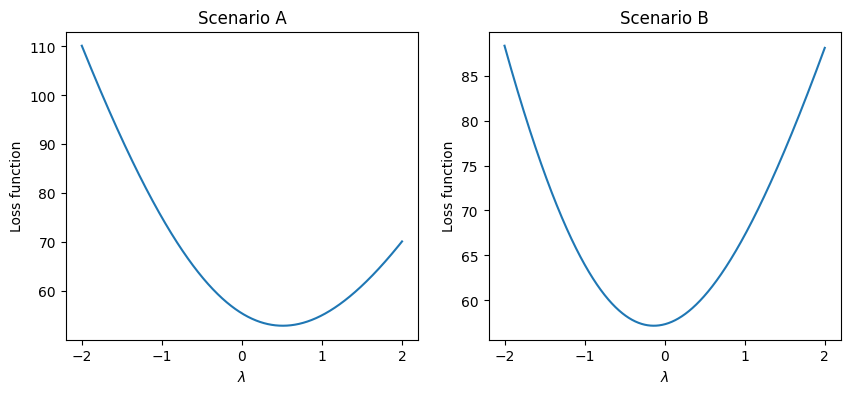

In [ ]:
k = 30  #liczba 0
m = 50  #liczba 1
n=k+m

#przewidywania f_i niedoskonałego modelu, wycentrowane w średnim y
rng = np.random.default_rng(seed=402)
f_i = rng.normal(loc=m/n, scale=0.5, size=n)
Y = np.concatenate([np.ones(m), np.zeros(k)])


def sigmoid(z):
    return 1 / ( 1 + np.exp(-1*z) )

def Loss(y, l):
    return np.sum( -y*np.log(sigmoid(l)) - (1-y)*np.log( 1 - sigmoid(l) ) )

l_A = np.linspace(-2, 2, 1000)


Loss_A = np.zeros_like(l_A)
Loss_B = np.zeros_like(l_A)

for i in range(l_A.size):
    Loss_A[i] = Loss(Y, l_A[i])
    Loss_B[i] = Loss(Y, f_i + l_A[i])


#Rysowanie wykresów
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(l_A, Loss_A)
ax[0].set_xlabel(r"$\lambda$")
ax[0].set_ylabel("Loss function")
ax[0].set_title("Scenario A")

ax[1].plot(l_A, Loss_B)
ax[1].set_xlabel(r"$\lambda$")
ax[1].set_ylabel("Loss function")
ax[1].set_title("Scenario B")

plt.show()

W celu zbadania krajobrazu funkcji straty dla binary cross-entropy rozważyliśmy dwa scenariusze: dopasowanie stałego parametru $\lambda$ od zera (Scenario A) oraz dopasowanie addytywnego przesunięcia $\lambda$ do istniejących predykcji $f_i$ pochodzących z poprzedniego etapu boostingowego (Scenario B). W obu przypadkach funkcję straty policzyliśmy dla szerokiego zakresu wartości $\lambda$, a wyniki przedstawiliśmy na wykresach.

W scenariuszu A funkcja straty zależy wyłącznie od proporcji klas w zbiorze danych. Ponieważ wszystkie obserwacje otrzymują tę samą wartość $\lambda$, suma strat upraszcza się do postaci zależnej jedynie od $\sigma(\lambda)$. W rezultacie wykres funkcji straty jest bardzo regularny, gładki i jednoznacznie wypukły, z jednym wyraźnym minimum. Wynika to z faktu, że binary cross-entropy jako funkcja $\lambda$ jest wypukła, a brak dodatkowych parametrów sprawia, że jej kształt jest prosty i symetryczny.

W scenariuszu B sytuacja jest bardziej złożona, ponieważ każda obserwacja ma inny punkt startowy $f_i$, a funkcja straty zależy od wartości $\sigma(f_i + \lambda)$. Mimo to wykres funkcji straty pozostaje gładki i wypukły. Wynika to z faktu, że każdy składnik straty jest funkcją wypukłą względem $\lambda$, a suma funkcji wypukłych również jest wypukła. Oznacza to, że krajobraz Loss function w scenariuszu B nie staje się nieregularny ani multimodalny, nawet jeśli wartości $f_i$ są losowe i zróżnicowane. Jedyną zauważalną różnicą jest zmiana kształtu krzywej, skutkujące przesunięciem minimum, a krzywa może być bardziej niesymetryczna, jednak nadal pozostaje jednoznacznie unimodalna.

Kluczowa trudność scenariusza B nie wynika więc z bardziej skomplikowanego krajobrazu straty, lecz z samej postaci równania optymalności. Warunek minimalizacji prowadzi do równania

$ \sum_{i=1}^n \sigma(f_i + \lambda^*) = m$,

którego nie da się rozwiązać analitycznie, ponieważ suma sigmoidalnych funkcji o różnych przesunięciach nie posiada funkcji odwrotnej możliwej do wyznaczenia analitycznie. W scenariuszu A wszystkie składniki były identyczne, co pozwalało sprowadzić problem do prostego równania i uzyskać rozwiązanie $\lambda^* = \log(m/k)$. W scenariuszu B taka redukcja nie jest możliwa, mimo że sama funkcja straty pozostaje wypukła i łatwa do minimalizacji metodami numerycznymi.

Podsumowując, krajobraz funkcji straty w scenariuszu A jest prostszy, ale oba scenariusze prowadzą do funkcji wypukłych i unimodalnych. Trudność scenariusza B nie wynika z nieregularności funkcji straty, lecz z braku ogólnej postaci rozwiązania równania optymalności, co jest konsekwencją nieliniowości sigmoidy i różnorodności wartości $f_i$. Minimum w scenariuszu B można jednak bez problemu znaleźć numerycznie, ponieważ funkcja jest gładka i ma jedno globalne minimum.